<a href="https://colab.research.google.com/github/darshanharore01-star/ThermaVista/blob/main/Scikitlearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#encoding categorial values


1 label encoding:text replace by number
bmw=[100]
audi=[010]
gender encoded
male-> 0
female->1
yes->1
no->0
2 one hot encoding


In [ ]:
import pandas as pd

# Create a dummy DataFrame
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'Gender': ['Female', 'Male', 'Male', 'Female', 'Female'],
    'Age': [24, 27, 22, 32, 29],
    'Passed': ['Yes', 'No', 'Yes', 'No', 'Yes'],
    'City': ['New York', 'London', 'Paris', 'Tokyo', 'London']
}
dummy_df = pd.DataFrame(data)

# Save the dummy DataFrame to 'sample_data.csv'
dummy_df.to_csv('sample_data.csv', index=False)
print("Created 'sample_data.csv' with dummy data including City column.")

Created 'sample_data.csv' with dummy data including City column.


LABEL ENCODING,ONE HOT ENCODING

Now that the `sample_data.csv` file exists, I will rerun the cell that performs label encoding after correcting the typo in `fit_tranform` to `fit_transform`.

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df=pd.read_csv("sample_data.csv")

df_label=df.copy() #original remain same

le=LabelEncoder()
df_label['Gender_Encoded']=le.fit_transform(df_label['Gender'])
df_label['Passed_Encoded']=le.fit_transform(df_label['Passed'])
print("Label Encoding")
print(df_label[['Name','Gender','Gender_Encoded','Passed','Passed_Encoded']].head())

#one hot
df_encoded=pd.get_dummies(df,columns=['City'])
print("One Hot Encoding")
print(df_encoded.head())

Label Encoding
      Name  Gender  Gender_Encoded Passed  Passed_Encoded
0    Alice  Female               0    Yes               1
1      Bob    Male               1     No               0
2  Charlie    Male               1    Yes               1
3    Diana  Female               0     No               0
4      Eve  Female               0    Yes               1
One Hot Encoding
      Name  Gender  Age Passed  City_London  City_New York  City_Paris  \
0    Alice  Female   24    Yes        False           True       False   
1      Bob    Male   27     No         True          False       False   
2  Charlie    Male   22    Yes        False          False        True   
3    Diana  Female   32     No        False          False       False   
4      Eve  Female   29    Yes         True          False       False   

   City_Tokyo  
0       False  
1       False  
2       False  
3        True  
4       False  


In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

scaler=StandardScaler()
X_scaled=scaler.fit_transform()

scaler=MinMaxScaler()
X_scaled=scaler.fit_transform()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
#to test machine mock interview of machine
data={
    'studyhours':[1,2,3,4,5,6],
    'Testscore':[40,50,60,70,80,90]
}

df=pd.DataFrame(data)

standard_scaler=StandardScaler()#create scalar value
standard_scaled=standard_scaler.fit_transform(df) #scale value using standard scaler formula
print("Standard Scaler")
print(pd.DataFrame(standard_scaled,columns=df.columns))
#output settle AROUND value of 0 not much diff in input output


Standard Scaler
   studyhours  Testscore
0    -1.46385   -1.46385
1    -0.87831   -0.87831
2    -0.29277   -0.29277
3     0.29277    0.29277
4     0.87831    0.87831
5     1.46385    1.46385


In [ ]:
#minmaxscaled
minmax_scaler=MinMaxScaler()
minmax_scaled=minmax_scaler.fit_transform(df)
print("MinMax Scaler")
print(pd.DataFrame(minmax_scaled,columns=df.columns))
#output

MinMax Scaler
   studyhours  Testscore
0         0.0        0.0
1         0.2        0.2
2         0.4        0.4
3         0.6        0.6
4         0.8        0.8
5         1.0        1.0


In [ ]:
#train model
X=df[['studyhours']]
y=df[['Testscore']]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#split data for training purpose 80% for training 20% for testing
print("X_train")
print(X_train)

print("X_test")
print(X_test)
print("y_train")
print(y_train)
print("y_test")
print(y_test)

X_train
   studyhours
5           6
2           3
4           5
3           4
X_test
   studyhours
0           1
1           2
y_train
   Testscore
5         90
2         60
4         80
3         70
y_test
   Testscore
0         40
1         50


SUPERVISED MACHINE LEARNING

linear regression

In [ ]:
 """
            ***linear regression***
 find pattern in old data
 straight line
 y=mx+c
 [[--]]<-2D list
   """
from sklearn.linear_model import LinearRegression

X=[[1],[2],[3],[4],[5]]
y=[40,50,65,75,90]
model=LinearRegression()
model.fit(X,y)
hours=float(input("enter hours: "))

predict_marks=model.predict([[hours]])
print(f"based on your hour {hours} you may score around {predict_marks}")

enter hours10
based on your hour 10.0 you may score around [151.5]


logistic regression

In [ ]:
"""            ***logistic regression***
output will be btw 0=no - 1=yes
hour study 1,2,3,4,5
Result.    F,F,P,P,P
"""
from sklearn.linear_model import LinearRegression
X=[[1],[2],[3],[4],[5]] #hour Studied input
y=[0,0,1,1,1] #result output 0-F,1-P

model=LinearRegression()
model.fit(X,y)
hours=float(input("enter hours: "))

result=model.predict([[hours]])[0] #[0] for yes no it is box which contain number

if result==1:
  print(f"based on hour {hours} you may pass")
else:
  print(f"based on hour {hours} you may fail")


enter hours: 2.5
based on hour 2.5 you may fail


k nearest neighbors(KNN)

In [ ]:
 """ ***k nearest neighbors(KNN)
person      A           B      C
weather     S           R      C
feeling     energetic   laazy  normal
play       yes         no     yes
Example:- used for email spam or not for healthy or not"""
"""
1.CHoose k=x no of values to consider
2.closest number of data point
3.how many number in each class
4.count
(2 yes 1 no) ---> yes
"""
from sklearn.neighbors import KNeighborsClassifier
X=[
    [180,7],
    [200,7.5],
    [250,8],
    [300,8.5],
    [330,9],
    [360,9.5]

]
#0 apple 1-Orange
y=[0,0,0,1,1,1]
model=KNeighborsClassifier(n_neighbors=3)
model.fit(X,y)
weight=float(input("Enter Weight"))
size=float(input("Enter Size"))

result=model.predict([[weight,size]])[0]
if result==0:
  print("Apple")
else:
  print("Orange")


Enter Weight120
Enter Size8
Apple


Decision Tree

In [ ]:
"""      Decision Tree
if machine learn from past example
is fever>100
  yes>cough?
    yes>flu
    no>maybe
  no-no flu

"""
from sklearn.tree import DecisionTreeClassifier
X=[
    [7,2], #apple [size,color]
    [8,3], #apple
    [9,8], #orange
    [10,9] #orange
]
y=[0,0,1,1] #0-apple 1-orange
model=DecisionTreeClassifier()
model.fit(X,y)
size=float(input("Enter fruit size in cm: "))
shade=float(input("Enter color shade range(1-10): "))
result=model.predict([[size,shade]])[0]
if result==0:
  print("Apple")
else:
  print("Orange")


Enter fruit size in cm: 8.5
Enter color shade range(1-10): 5
Apple


fit() training stage learn from data fig out pattern

predict() exam, for new case what output


overfitting-memorize data deeply not more then that

underfitting-not understand yet dont have enough study

goodfit-balanced learning

**********MAstering model evaluation**********

In [ ]:
"""
type:
1.sklearn metrics=comprehsensive model evaluation
2.Regression metrics=MAE,MSE,RMSE
3.Confusion matrix=analyze model performance
4.classification metrics=accuracy,precision,recall and F1-score

"""

In [ ]:
"""
sklearn.metrics
model accuracy
100%->(modelguess)95% -> 5% error
how often right or wrong?
"""
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
#true answer
y_true=[1,0,1,1,0,1,0]
#model prediction (what it guess)
y_pred=[1,0,1,0,0,1,1]
print("Accuracy Score")
print(accuracy_score(y_true,y_pred)) #how many % correct guessing done
print("Precision Score")
print(precision_score(y_true,y_pred)) #how many +ve prediction were actually correct
print("Recall Score")
print(recall_score(y_true,y_pred))#how many real +ve get
print("F1 Score")
print(f1_score(y_true,y_pred))#mix precision and recall = f1

Accuracy Score
0.7142857142857143
Precision Score
0.75
Recall Score
0.75
F1 Score
0.75


In [ ]:
#confusion matrix

"""
student   actualresult  predictedresult.   type
  A.         p.             p.             true +ve(TP)
  B.         f.             f              true -ve(TN)
  C.         p.             f              false -ve(FN)
  D.         f.             p              false +ve(FP)

"""
from sklearn.metrics import confusion_matrix
y_true=[1,0,1,1,0,1,0]
y_pred=[1,0,1,0,0,1,1]
print("Confusion Matrix")
print(confusion_matrix(y_true,y_pred))
"""
output:
[[TN FP]
 [FN TP]]

Confusion Matrix
[[2 1]
 [1 3]]


In [ ]:
#             MAE.    MSE.     RMSE
"""
Student   real_m    pred_m   mistake
 A          90        85       5
 B          80        70       10
 C          70        60       10
 D          60        50       10

"""
"""
    *mean absolute error*: how far is my model
1. take the mistake diff
2.remove the minus sign
3.add
4.divide
    *mean squared error*
1.Mistake square
2.add
3.divide by no. of student
MSE=add(mistake**mistake)/no. of student
    *root mean sq error*
    RMSE=sqrt(MSE)

"""

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np
y_true=[90,80,70,60]
y_pred=[85,70,60,50]
print("Mean Absolute Error")
print(mean_absolute_error(y_true,y_pred))
print("Mean Squared Error")
print(mean_squared_error(y_true,y_pred))
print("Root Mean Squared Error")
print(np.sqrt(mean_squared_error(y_true,y_pred)))


Mean Absolute Error
8.75
Mean Squared Error
81.25
Root Mean Squared Error
9.013878188659973


Project 1 basic data load linear regression

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np
data={
    'hours':[1,2,3,4,5,6],
    'score':[52,57,65,70,75,80]
}

df=pd.DataFrame(data)
X=df[['hours']]
y=df[['score']]

model=LinearRegression()
model.fit(X,y)


predict_score=model.predict(X)
mae=mean_squared_error(y,predict_score)
print(f"Mean Absolute Error: {mae}")
mse=mean_squared_error(y,predict_score)
print(f"Mean Squared Error: {mse}")
rmse=np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse}")

new_prediction=model.predict([[7]])
print(f"Prediction for 7 hours: {new_prediction[0]}")


Mean Absolute Error: 0.6285714285714282
Mean Squared Error: 0.6285714285714282
Root Mean Squared Error: 0.7928249671720916
Prediction for 7 hours: [86.4]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
"""
3 Step formula
1-X and y numeric?
Scatter plot
relationship

2-is one column a category
barplot/count plot

3-want to see a distribution
shape? Histogram/KDE plot/Box plot
"""


'\n3 Step formula\n1-X and y numeric?\nScatter plot\nrelationship\n\n2-is one column a category\nbarplot/count plot\n\n3-want to see a distribution\nshape? Histogram/KDE plot/Box plot\n'

student_id                 600496
weekly_self_study_hours    600496
attendance_percentage      600496
class_participation        600496
total_score                600496
grade                      600496
dtype: int64
Mean Absolute Error:  7.17
Mean Squared Error:  81.15
Root Mean Squared Error:  9.01
R-squared:  0.66


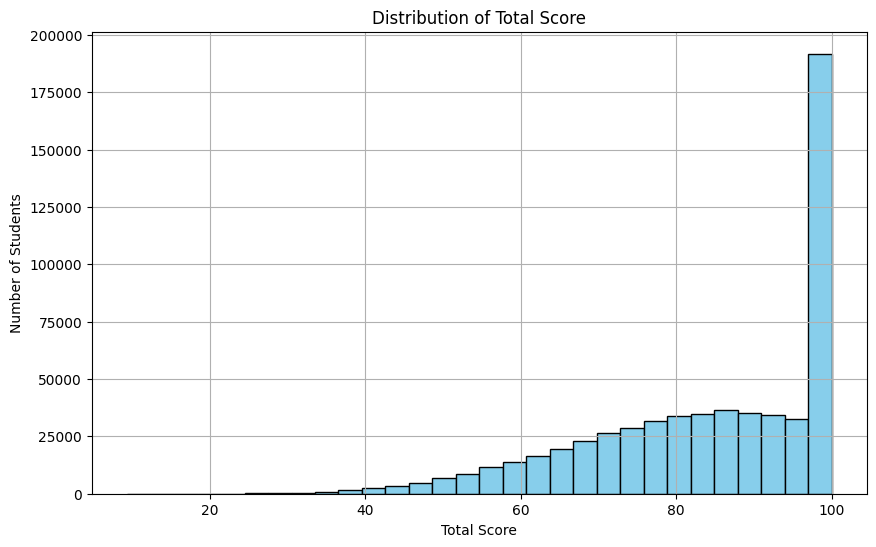

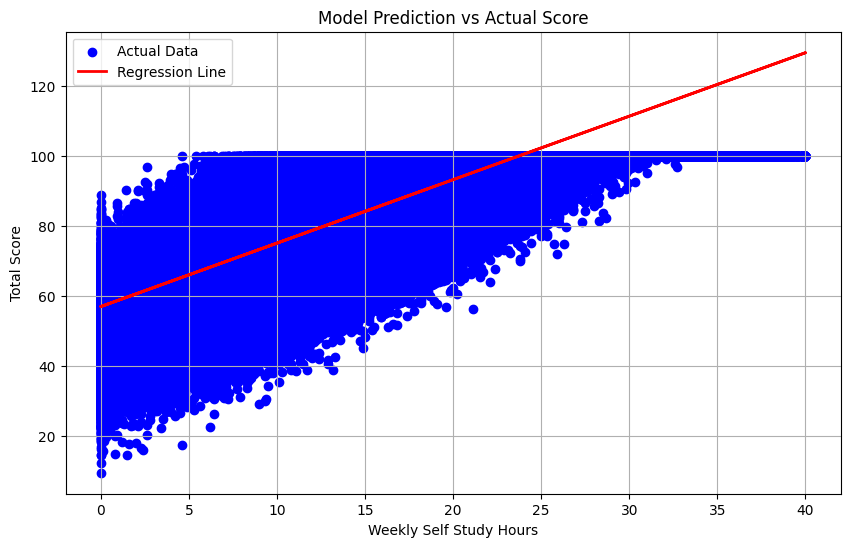

Prediction for 9 hours: 73.32


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = pd.read_csv("student_performance.csv")
X = data[['weekly_self_study_hours']]
y = data['total_score']  # 1D Series for clean scalar outputs

print(data.count())

model = LinearRegression()
model.fit(X, y)

predict_score = model.predict(X)

# Evaluation metrics
mae = mean_absolute_error(y, predict_score)
print("Mean Absolute Error: ", round(mae, 2))

mse = mean_squared_error(y, predict_score)
print("Mean Squared Error: ", round(mse, 2))

rmse = np.sqrt(mse)
print("Root Mean Squared Error: ", round(rmse, 2))

r2 = r2_score(y, predict_score)
print("R-squared: ", round(r2, 2))

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(data["total_score"], bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Total Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Total Score")
plt.grid(True)
plt.show()

# Scatter plot with regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, predict_score, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Total Score")
plt.title("Model Prediction vs Actual Score")
plt.legend()
plt.grid(True)
plt.show()

# Prediction for new input
new_hours = 9
new_input = pd.DataFrame({'weekly_self_study_hours': [new_hours]})
new_prediction = model.predict(new_input)
print(f"Prediction for {new_hours} hours: {new_prediction[0]:.2f}")
